# Amazon Beauty 2018: Validation Checks and EDA

Companion to `amazon_beauty_all_models_etl_v1.ipynb`.

1. **EDA on the raw data**: rating distribution and how many users survive each filter.
2. **EDA on the model-ready data**: sequence lengths, item popularity, time coverage, unseen test items.
3. **Validation checks**: one function that checks the model-ready table, run on the real data (should pass) and on deliberately corrupted copies (each should fail).
4. **Split fingerprints**: SHA-256 checksums of the split files, so a split can be identified exactly.

**Before running:** run the ETL notebook in the same Colab session first, or upload `amazon_beauty_model_ready.csv` and the three split CSVs into `amazon_beauty_prepared_outputs/`.

In [1]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RATINGS_URL = (
    "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_v2/"
    "categoryFilesSmall/All_Beauty.csv"
)
OUTPUT_DIR = Path("amazon_beauty_prepared_outputs")
MODEL_READY_FILE = OUTPUT_DIR / "amazon_beauty_model_ready.csv"

POSITIVE_THRESHOLD = 4
MIN_INTERACTIONS = 5

## 1. EDA on the raw data

The official ratings-only file has no header and is ordered item, user, rating, timestamp.

In [2]:
raw = pd.read_csv(
    RATINGS_URL,
    header=None,
    names=["item_id", "user_id", "rating", "timestamp"],
)
raw["rating"] = pd.to_numeric(raw["rating"], errors="coerce")
raw["timestamp"] = pd.to_numeric(raw["timestamp"], errors="coerce")
raw = raw.dropna(subset=["user_id", "item_id", "rating", "timestamp"])

print(f"Raw rows:     {len(raw):,}")
print(f"Unique users: {raw['user_id'].nunique():,}")
print(f"Unique items: {raw['item_id'].nunique():,}")

Raw rows:     371,345
Unique users: 324,038
Unique items: 32,586


Rating distribution (share of rows):
rating
1.0    10.6%
2.0     5.5%
3.0     8.0%
4.0    14.2%
5.0    61.8%
Name: proportion, dtype: object


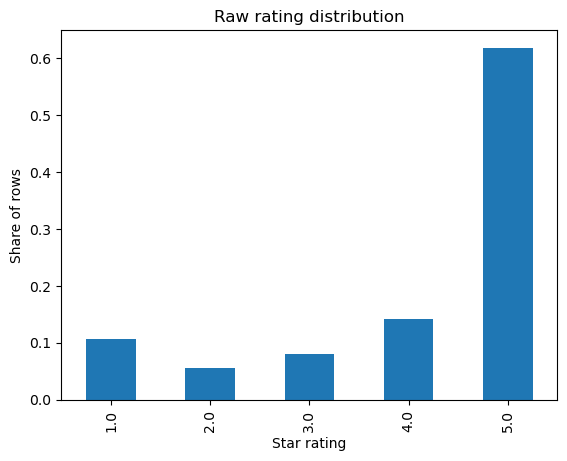

In [3]:
rating_share = raw["rating"].value_counts(normalize=True).sort_index()
print("Rating distribution (share of rows):")
print((rating_share * 100).round(1).astype(str) + "%")

ax = rating_share.plot(kind="bar", title="Raw rating distribution")
ax.set_xlabel("Star rating")
ax.set_ylabel("Share of rows")
plt.show()

### How many users survive each filter

This explains why 371,345 rows become 3,313. It also shows how many users would remain if all ratings were kept as interactions (the original SASRec protocol) instead of ratings 4–5 only.

Users in raw data:                         324,038
Users with exactly 1 rating:               294,400 (90.9%)
Users with >= 5 ratings of any value:       722
Users with >= 5 positive ratings (used):    590
Users with >= 3 positive ratings:          3,617


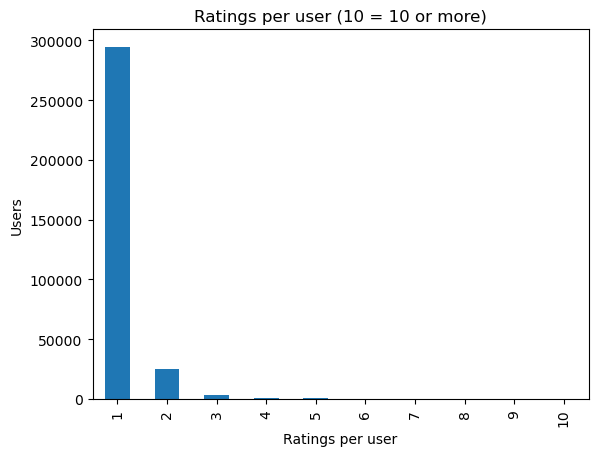

In [4]:
dedup = (
    raw.sort_values(["user_id", "timestamp", "item_id"])
    .drop_duplicates(subset=["user_id", "item_id"], keep="first")
)

per_user_all = dedup.groupby("user_id").size()
per_user_pos = dedup[dedup["rating"] >= POSITIVE_THRESHOLD].groupby("user_id").size()

print(f"Users in raw data:                         {per_user_all.size:,}")
print(f"Users with exactly 1 rating:               {(per_user_all == 1).sum():,} "
      f"({(per_user_all == 1).mean():.1%})")
print(f"Users with >= {MIN_INTERACTIONS} ratings of any value:       "
      f"{(per_user_all >= MIN_INTERACTIONS).sum():,}")
print(f"Users with >= {MIN_INTERACTIONS} positive ratings (used):    "
      f"{(per_user_pos >= MIN_INTERACTIONS).sum():,}")
print(f"Users with >= 3 positive ratings:          {(per_user_pos >= 3).sum():,}")

ax = per_user_all.clip(upper=10).value_counts().sort_index().plot(
    kind="bar", title="Ratings per user (10 = 10 or more)"
)
ax.set_xlabel("Ratings per user")
ax.set_ylabel("Users")
plt.show()

## 2. EDA on the model-ready data

In [5]:
def build_model_ready(raw_ratings):
    """Same steps as amazon_beauty_all_models_etl_v1.ipynb (cells 7, 11, 12)."""
    df = raw_ratings[["user_id", "item_id", "rating", "timestamp"]].copy()
    df["user_id"] = df["user_id"].astype("string").str.strip()
    df["item_id"] = df["item_id"].astype("string").str.strip()
    df = df.dropna(subset=["user_id", "item_id", "rating", "timestamp"])
    df = df[df["user_id"].ne("") & df["item_id"].ne("")]
    df = df[df["rating"].between(1, 5)]
    df = df[df["timestamp"] > 0]
    df = df.sort_values(["user_id", "timestamp", "item_id"])
    df = df.drop_duplicates()
    df = df.drop_duplicates(subset=["user_id", "item_id"], keep="first")
    df = df[df["rating"] >= POSITIVE_THRESHOLD].copy()
    counts = df.groupby("user_id").size()
    df = df[df["user_id"].isin(counts[counts >= MIN_INTERACTIONS].index)].copy()

    df["domain"] = "beauty"
    df["datetime"] = pd.to_datetime(df["timestamp"], unit="s", errors="coerce")
    df["global_item_key"] = "beauty:" + df["item_id"]
    df["client_id"] = "beauty:" + df["user_id"]
    user_to_index = {v: i for i, v in enumerate(sorted(df["user_id"].unique()), start=1)}
    item_to_index = {v: i for i, v in enumerate(sorted(df["global_item_key"].unique()), start=1)}
    df["user_index"] = df["user_id"].map(user_to_index).astype("int64")
    df["item_index"] = df["global_item_key"].map(item_to_index).astype("int64")

    df = df.sort_values(["user_id", "timestamp", "item_id"]).reset_index(drop=True)
    df["sequence_position"] = df.groupby("user_id").cumcount() + 1
    length = df.groupby("user_id")["user_id"].transform("size")
    df["split"] = np.where(
        df["sequence_position"] == length, "test",
        np.where(df["sequence_position"] == length - 1, "validation", "train"),
    )
    df = df.sort_values(["user_index", "sequence_position"]).reset_index(drop=True)
    return df[[
        "user_id", "item_id", "rating", "timestamp", "datetime", "domain",
        "global_item_key", "client_id", "user_index", "item_index",
        "split", "sequence_position",
    ]]


if not MODEL_READY_FILE.exists():
    print("ETL output not found, so building it here with the same steps as the ETL notebook.")
    OUTPUT_DIR.mkdir(exist_ok=True)
    built = build_model_ready(raw)
    built.to_csv(MODEL_READY_FILE, index=False)
    for split in ["train", "validation", "test"]:
        built[built["split"] == split].to_csv(
            OUTPUT_DIR / f"amazon_beauty_{split}.csv", index=False
        )

model_ready = pd.read_csv(MODEL_READY_FILE, dtype={"user_id": str, "item_id": str})
print(f"Rows: {len(model_ready):,}")
print(f"Users: {model_ready['user_id'].nunique():,}")
print(f"Items: {model_ready['item_id'].nunique():,}")
print(model_ready["split"].value_counts())
model_ready.head()


ETL output not found, so building it here with the same steps as the ETL notebook.
Rows: 3,313
Users: 590
Items: 1,211
split
train         2133
validation     590
test           590
Name: count, dtype: int64


,user_id,item_id,rating,timestamp,datetime,domain,global_item_key,client_id,user_index,item_index,split,sequence_position
0,A105A034ZG9EHO,B000CR4ER6,4.0,1155081600,2006-08-09,beauty,beauty:B000CR4ER6,beauty:A105A034ZG9EHO,1,48,train,1
1,A105A034ZG9EHO,B000EIOAFY,5.0,1268697600,2010-03-16,beauty,beauty:B000EIOAFY,beauty:A105A034ZG9EHO,1,51,train,2
2,A105A034ZG9EHO,B0009RF9DW,5.0,1404604800,2014-07-06,beauty,beauty:B0009RF9DW,beauty:A105A034ZG9EHO,1,42,train,3
3,A105A034ZG9EHO,B000FI4S1E,5.0,1404604800,2014-07-06,beauty,beauty:B000FI4S1E,beauty:A105A034ZG9EHO,1,58,train,4
4,A105A034ZG9EHO,B000URXP6E,5.0,1404604800,2014-07-06,beauty,beauty:B000URXP6E,beauty:A105A034ZG9EHO,1,91,train,5


Interactions per user (sequence length):
count    590.00
mean       5.62
std        1.56
min        5.00
25%        5.00
50%        5.00
75%        6.00
max       21.00
dtype: float64


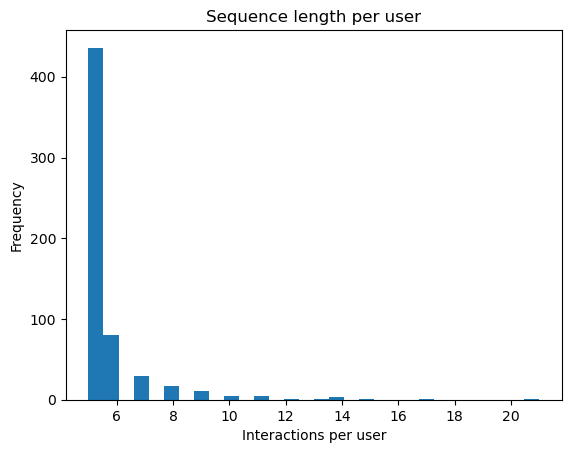

In [6]:
seq_len = model_ready.groupby("user_id").size()
print("Interactions per user (sequence length):")
print(seq_len.describe().round(2))

ax = seq_len.plot(kind="hist", bins=30, title="Sequence length per user")
ax.set_xlabel("Interactions per user")
plt.show()

Items with only 1 interaction: 889 (73.4%)
Share of interactions on the top 10% of items: 60.0%


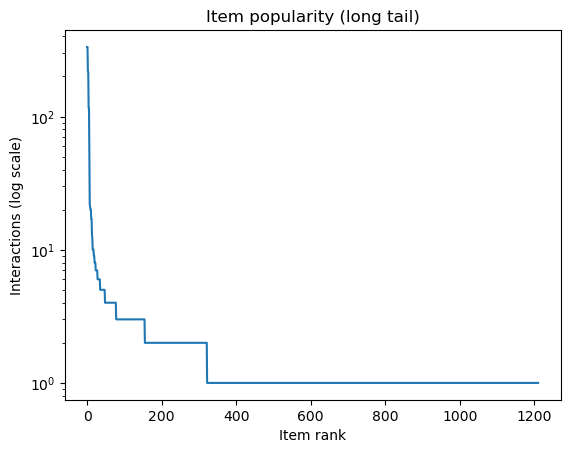

In [7]:
item_pop = model_ready.groupby("item_id").size().sort_values(ascending=False)
top_10pct = max(1, int(len(item_pop) * 0.10))

print(f"Items with only 1 interaction: {(item_pop == 1).sum():,} "
      f"({(item_pop == 1).mean():.1%})")
print(f"Share of interactions on the top 10% of items: "
      f"{item_pop.iloc[:top_10pct].sum() / item_pop.sum():.1%}")

ax = item_pop.reset_index(drop=True).plot(
    logy=True, title="Item popularity (long tail)"
)
ax.set_xlabel("Item rank")
ax.set_ylabel("Interactions (log scale)")
plt.show()

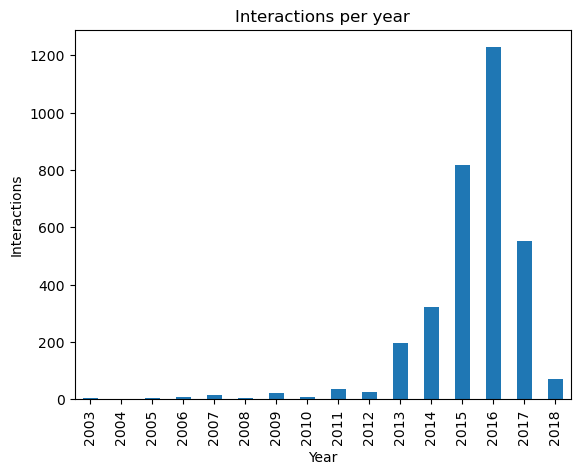

In [8]:
years = pd.to_datetime(model_ready["timestamp"], unit="s").dt.year
ax = years.value_counts().sort_index().plot(
    kind="bar", title="Interactions per year"
)
ax.set_xlabel("Year")
ax.set_ylabel("Interactions")
plt.show()

### Items in validation/test that never appear in training

SASRec cannot learn a useful embedding for an item it never sees during training, so these test cases are effectively item cold start.

In [9]:
train_items = set(model_ready.loc[model_ready["split"] == "train", "item_id"])
for split in ["validation", "test"]:
    rows = model_ready[model_ready["split"] == split]
    unseen = ~rows["item_id"].isin(train_items)
    print(f"{split:<10} rows: {len(rows):,}   "
          f"target item never seen in training: {unseen.sum():,} ({unseen.mean():.1%})")

validation rows: 590   target item never seen in training: 171 (29.0%)
test       rows: 590   target item never seen in training: 481 (81.5%)


In [10]:
same_day = (
    model_ready.groupby(["user_id", "timestamp"]).size().gt(1).groupby("user_id").any()
)
print(f"Users with 2+ interactions on the same day: {same_day.sum():,} "
      f"of {same_day.size:,} ({same_day.mean():.1%})")
print("Amazon timestamps are day-level, so same-day order is broken by item_id.")

Users with 2+ interactions on the same day: 497 of 590 (84.2%)
Amazon timestamps are day-level, so same-day order is broken by item_id.


## 3. Validation checks

`validate_model_ready` returns a list of problems. An empty list means the table passed.

In [11]:
REQUIRED_COLUMNS = [
    "user_id", "item_id", "rating", "timestamp", "datetime", "domain",
    "global_item_key", "client_id", "user_index", "item_index",
    "split", "sequence_position",
]


def validate_model_ready(df):
    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        return [f"Missing required columns: {missing}"]

    errors = []

    nulls = df[REQUIRED_COLUMNS].isna().sum()
    if nulls.any():
        errors.append(f"Null values: {nulls[nulls > 0].to_dict()}")

    blank = (
        df["user_id"].astype(str).str.strip().eq("")
        | df["item_id"].astype(str).str.strip().eq("")
    )
    if blank.any():
        errors.append(f"Blank user or item IDs: {int(blank.sum())} rows")

    bad_rating = ~df["rating"].between(1, 5)
    if bad_rating.any():
        errors.append(f"Ratings outside 1-5: {int(bad_rating.sum())} rows")

    if (df["timestamp"] <= 0).any():
        errors.append(f"Non-positive timestamps: {int((df['timestamp'] <= 0).sum())} rows")

    if df.duplicated().any():
        errors.append(f"Exact duplicate rows: {int(df.duplicated().sum())}")

    if df.duplicated(subset=["user_id", "item_id"]).any():
        errors.append(
            f"Repeated user-item pairs: {int(df.duplicated(subset=['user_id', 'item_id']).sum())}"
        )

    counts = df.groupby(["user_id", "split"]).size().unstack(fill_value=0)
    for split in ["train", "validation", "test"]:
        if split not in counts.columns:
            counts[split] = 0
    bad_split = counts[
        (counts["train"] < 1) | (counts["validation"] != 1) | (counts["test"] != 1)
    ]
    if len(bad_split):
        errors.append(
            f"Users without exactly 1 validation, 1 test and >=1 train row: {len(bad_split)}"
        )

    times = df.groupby(["user_id", "split"])["timestamp"].agg(["min", "max"]).unstack("split")
    try:
        leak = times[
            (times[("max", "train")] > times[("min", "validation")])
            | (times[("max", "validation")] > times[("min", "test")])
        ]
        if len(leak):
            errors.append(f"Temporal leakage (later split dated before earlier split): {len(leak)} users")
    except KeyError:
        pass

    for col in ["user_index", "item_index"]:
        values = np.sort(df[col].unique())
        if not np.array_equal(values, np.arange(1, len(values) + 1)):
            errors.append(f"{col} is not contiguous from 1")

    if df.groupby("user_id")["user_index"].nunique().max() > 1:
        errors.append("A user_id maps to more than one user_index")
    if df.groupby("item_id")["item_index"].nunique().max() > 1:
        errors.append("An item_id maps to more than one item_index")

    return errors


def report(name, df):
    errors = validate_model_ready(df)
    status = "PASSED" if not errors else "FAILED"
    print(f"[{status}] {name}")
    for e in errors:
        print("    -", e)
    return errors

### Real data: should pass

In [12]:
assert report("Real model-ready table", model_ready) == []

[PASSED] Real model-ready table


### Deliberately corrupted copies: each should fail

Each copy has one defect injected. The check must catch every one.

In [13]:
def corrupt(df, how):
    bad = df.copy()
    if how == "null user_id":
        bad.loc[bad.index[0], "user_id"] = None
    elif how == "rating of 7":
        bad.loc[bad.index[0], "rating"] = 7.0
    elif how == "negative timestamp":
        bad.loc[bad.index[0], "timestamp"] = -1
    elif how == "duplicated row":
        bad = pd.concat([bad, bad.iloc[[0]]], ignore_index=True)
    elif how == "test item dated before training":
        user = bad["user_id"].iloc[0]
        rows = bad["user_id"] == user
        first_train = bad.loc[rows & (bad["split"] == "train"), "timestamp"].min()
        bad.loc[rows & (bad["split"] == "test"), "timestamp"] = first_train - 86_400
    elif how == "missing split column":
        bad = bad.drop(columns=["split"])
    elif how == "gap in item_index":
        top = bad["item_index"].max()
        bad.loc[bad["item_index"] == top, "item_index"] = top + 5
    return bad


CORRUPTIONS = [
    "null user_id",
    "rating of 7",
    "negative timestamp",
    "duplicated row",
    "test item dated before training",
    "missing split column",
    "gap in item_index",
]

caught = 0
for how in CORRUPTIONS:
    if report(f"Corrupted: {how}", corrupt(model_ready, how)):
        caught += 1

print(f"\nCaught {caught} of {len(CORRUPTIONS)} injected defects.")
assert caught == len(CORRUPTIONS)

[FAILED] Corrupted: null user_id
    - Null values: {'user_id': 1}
[FAILED] Corrupted: rating of 7
    - Ratings outside 1-5: 1 rows
[FAILED] Corrupted: negative timestamp
    - Non-positive timestamps: 1 rows
[FAILED] Corrupted: duplicated row
    - Exact duplicate rows: 1
    - Repeated user-item pairs: 1
[FAILED] Corrupted: test item dated before training
    - Temporal leakage (later split dated before earlier split): 1 users
[FAILED] Corrupted: missing split column
    - Missing required columns: ['split']
[FAILED] Corrupted: gap in item_index
    - item_index is not contiguous from 1

Caught 7 of 7 injected defects.


## 4. Split fingerprints

These SHA-256 checksums identify the exact version of each split file, so anyone rerunning the pipeline can confirm they get the same split.

In [14]:
for name in [
    "amazon_beauty_model_ready.csv",
    "amazon_beauty_train.csv",
    "amazon_beauty_validation.csv",
    "amazon_beauty_test.csv",
]:
    path = OUTPUT_DIR / name
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    rows = sum(1 for _ in path.open()) - 1
    print(f"{name:<35} rows={rows:>5,}  sha256={digest[:16]}...")

amazon_beauty_model_ready.csv       rows=3,313  sha256=68d2ce466213e1bf...
amazon_beauty_train.csv             rows=2,133  sha256=9cac23fe135facd2...
amazon_beauty_validation.csv        rows=  590  sha256=ff98774ce0e74a74...
amazon_beauty_test.csv              rows=  590  sha256=58b92a35bf917bb7...
